In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv(r"C:\Users\aksha\Downloads\train_and_test2.csv")

df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [25]:
print("="*50)
print("DATASET INFORMATION")
print("="*50)

print("\nShape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics")
print(df.describe())

DATASET INFORMATION

Shape: (1309, 28)

Data Types
Passengerid      int64
Age            float64
Fare           float64
Sex              int64
sibsp            int64
zero             int64
zero.1           int64
zero.2           int64
zero.3           int64
zero.4           int64
zero.5           int64
zero.6           int64
Parch            int64
zero.7           int64
zero.8           int64
zero.9           int64
zero.10          int64
zero.11          int64
zero.12          int64
zero.13          int64
zero.14          int64
Pclass           int64
zero.15          int64
zero.16          int64
Embarked       float64
zero.17          int64
zero.18          int64
2urvived         int64
dtype: object

Missing Values
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zer

In [37]:
def clean_data(df):

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Remove columns with "zero" in their name
    cols_to_drop = [col for col in df.columns if "zero" in col.lower()]
    df = df.drop(columns=cols_to_drop)

    # Fill missing numeric values with median
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values with mode
    categorical_cols = df.select_dtypes(include="object").columns

    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Remove extra spaces from text
    for col in categorical_cols:
        df[col] = df[col].str.strip()

    return df

In [38]:
clean_df = clean_data(df)

clean_df.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [ ]:
print("Shape:", clean_df.shape)

print("\nMissing Values")
print(clean_df.isnull().sum())

print("\nDuplicate Rows")
print(clean_df.duplicated().sum())

Shape: (1309, 9)

Missing Values
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
2urvived       0
dtype: int64

Duplicate Rows
0


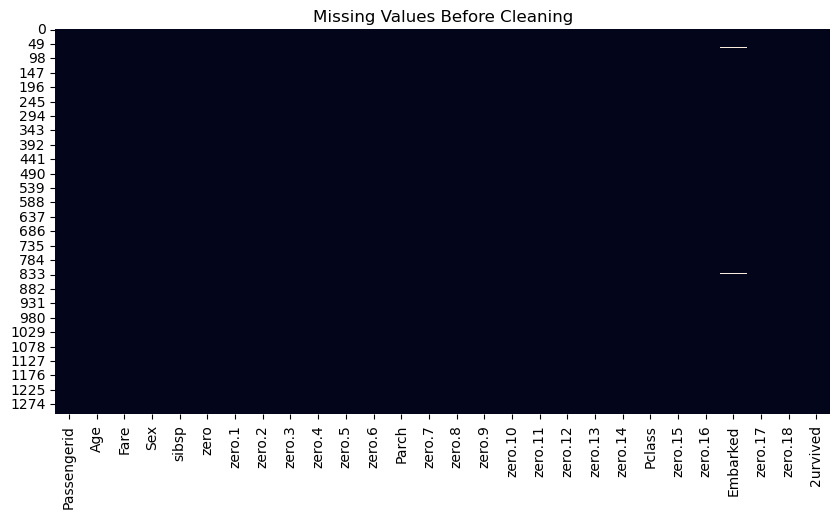

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Before Cleaning")

plt.show()

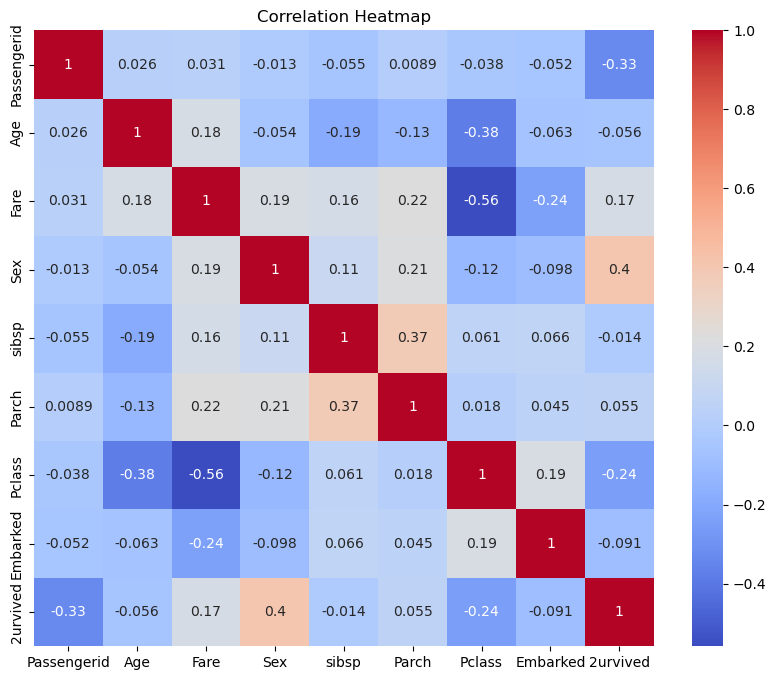

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(clean_df.corr(numeric_only=True),
            cmap="coolwarm",
            annot=True)

plt.title("Correlation Heatmap")

plt.show()

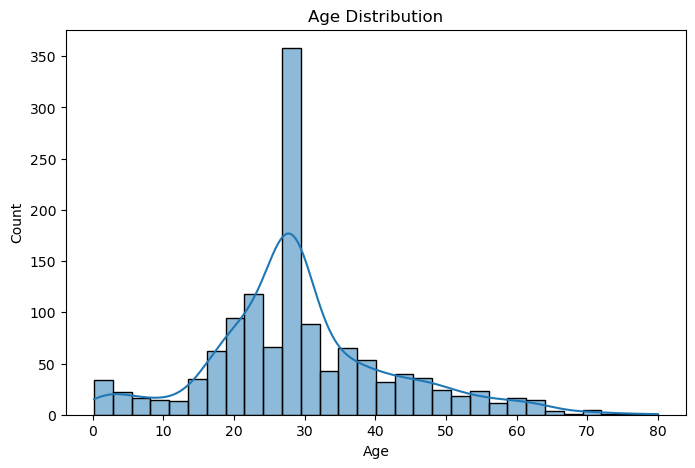

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(clean_df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

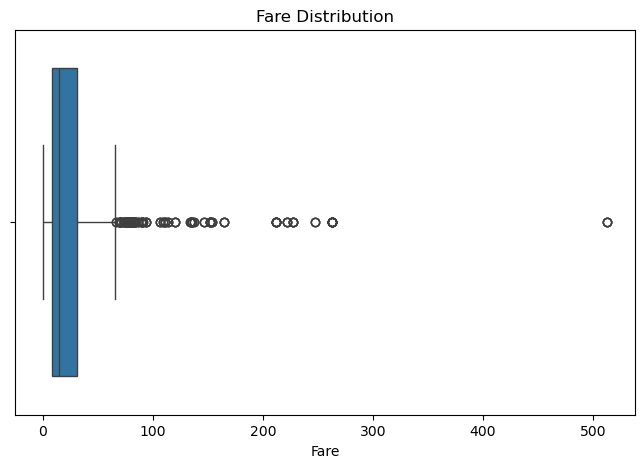

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=clean_df["Fare"])

plt.title("Fare Distribution")

plt.show()

In [ ]:
clean_df.to_csv("cleaned_dataset.csv", index=False)

In [ ]:
cols_to_drop = [col for col in df.columns if "zero" in col.lower()]

In [ ]:
report = f"""
DATA CLEANING REPORT
====================

Original Dataset Shape : {df.shape}

Cleaned Dataset Shape : {clean_df.shape}

Missing Values Remaining : {clean_df.isnull().sum().sum()}

Duplicate Rows Remaining : {clean_df.duplicated().sum()}

Columns Removed : {len(cols_to_drop)}

Cleaning Operations Performed:
- Removed duplicate rows
- Removed unnecessary zero columns
- Filled missing numerical values
- Filled missing categorical values
- Standardized text values
"""

print(report)

with open("cleaning_report.txt", "w") as file:
    file.write(report)


DATA CLEANING REPORT

Original Dataset Shape : (1309, 28)

Cleaned Dataset Shape : (1309, 9)

Missing Values Remaining : 0

Duplicate Rows Remaining : 0

Columns Removed : 19

Cleaning Operations Performed:
- Removed duplicate rows
- Removed unnecessary zero columns
- Filled missing numerical values
- Filled missing categorical values
- Standardized text values



In [39]:
print("="*50)
print("BEFORE CLEANING")
print("="*50)

print("Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\n")

print("="*50)
print("AFTER CLEANING")
print("="*50)

print("Shape:", clean_df.shape)
print("Missing Values:", clean_df.isnull().sum().sum())
print("Duplicate Rows:", clean_df.duplicated().sum())

BEFORE CLEANING
Shape: (1309, 28)
Missing Values: 2
Duplicate Rows: 0


AFTER CLEANING
Shape: (1309, 9)
Missing Values: 0
Duplicate Rows: 0


In [40]:
report = f"""
=============================
DATA CLEANING REPORT
=============================

Original Dataset Shape : {df.shape}

Cleaned Dataset Shape : {clean_df.shape}

Rows Removed : {df.shape[0] - clean_df.shape[0]}

Columns Removed : {len(cols_to_drop)}

Removed Columns:
{', '.join(cols_to_drop)}

Missing Values Remaining : {clean_df.isnull().sum().sum()}

Duplicate Rows Remaining : {clean_df.duplicated().sum()}

Cleaning Operations Performed:
✔ Removed duplicate rows
✔ Removed unnecessary columns
✔ Filled missing numerical values using Median
✔ Filled missing categorical values using Mode
✔ Removed extra spaces from text
✔ Exported cleaned dataset

Data cleaning completed successfully.
"""

print(report)


DATA CLEANING REPORT

Original Dataset Shape : (1309, 28)

Cleaned Dataset Shape : (1309, 9)

Rows Removed : 0

Columns Removed : 19

Removed Columns:
zero, zero.1, zero.2, zero.3, zero.4, zero.5, zero.6, zero.7, zero.8, zero.9, zero.10, zero.11, zero.12, zero.13, zero.14, zero.15, zero.16, zero.17, zero.18

Missing Values Remaining : 0

Duplicate Rows Remaining : 0

Cleaning Operations Performed:
✔ Removed duplicate rows
✔ Removed unnecessary columns
✔ Filled missing numerical values using Median
✔ Filled missing categorical values using Mode
✔ Removed extra spaces from text
✔ Exported cleaned dataset

Data cleaning completed successfully.



In [41]:
with open("cleaning_report.txt", "w") as file:
    file.write(report)

print("Report Saved Successfully!")

Report Saved Successfully!


In [42]:
clean_df.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!


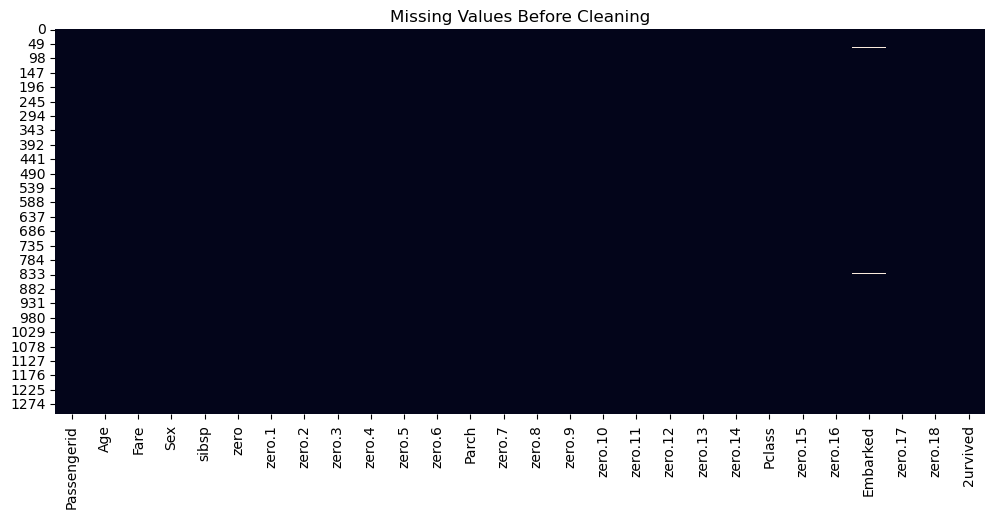

In [43]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Before Cleaning")

plt.show()

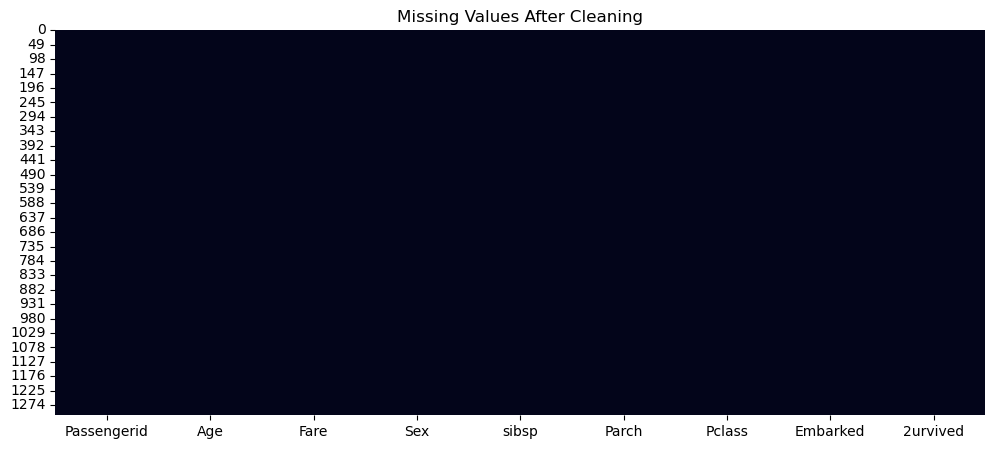

In [44]:
plt.figure(figsize=(12,5))

sns.heatmap(clean_df.isnull(), cbar=False)

plt.title("Missing Values After Cleaning")

plt.show()

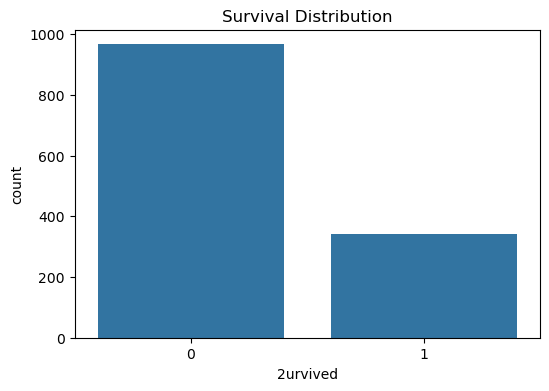

In [58]:
plt.figure(figsize=(6,4))

sns.countplot(data=clean_df, x="2urvived")

plt.title("Survival Distribution")

plt.show()

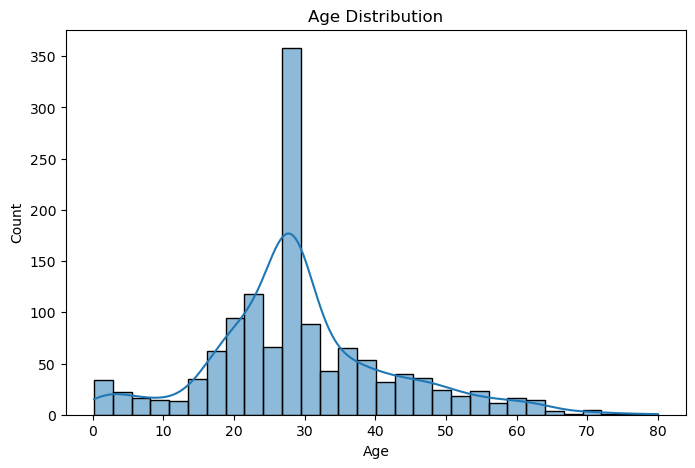

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(clean_df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

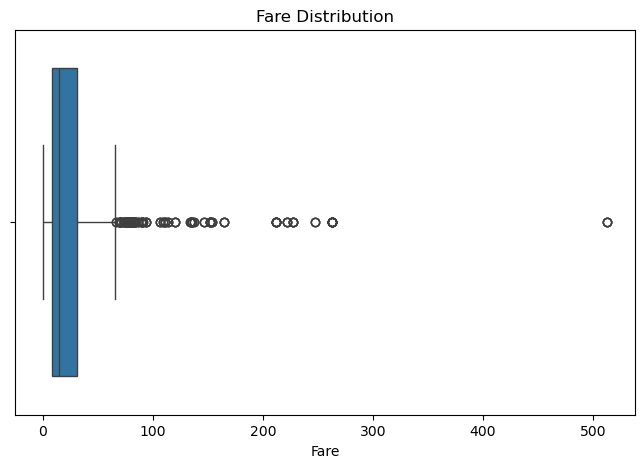

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(x=clean_df["Fare"])

plt.title("Fare Distribution")

plt.show()

In [59]:
plt.savefig("missing_values_before.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>